Implement `fuzzy_c_means(X, c, m=2.0, max_iter=100, tol=1e-5)` from scratch in Python (do NOT use external libraries like `fcmeans`).

Algorithm steps:
- Initialize a random membership matrix \( U \in \mathbb{R}^{N times c} \), ensuring each row sums to 1.
- Update cluster centers \( V \) using the weighted average of data points.
- Update membership values based on distances and fuzzifier \( m \).
- Stop when the maximum change in \( U \) is less than `tol` or `max_iter` is reached.

Return the final cluster centers, the membership matrix, and the number of iterations used.
Test the function on a 2-D blobs dataset (`sklearn.datasets.make_blobs`, 3 clusters, 300 points) and plot:
- The data points colored by their highest membership
- The cluster centers

In [ ]:
#Clustering
import numpy as np

def fuzzy_c_means(X, c, m=2.0, max_iter=100, tol=1e-5):
    N = X.shape[0]

    # Random membership matrix
    U = np.random.rand(N, c)
    U = U / np.sum(U, axis=1, keepdims=True)

    for iteration in range(max_iter):

        U_old = U.copy()

        # Update centers
        Um = U ** m

        centers = (Um.T @ X) / np.sum(Um.T, axis=1, keepdims=True)

        # Distances
        dist = np.zeros((N, c))

        for j in range(c):
            dist[:, j] = np.linalg.norm(X - centers[j], axis=1)

        dist = np.fmax(dist, 1e-10)

        # Update memberships
        for i in range(N):
            for j in range(c):

                denom = np.sum(
                    (dist[i, j] / dist[i, :]) ** (2/(m-1))
                )

                U[i, j] = 1 / denom

        # Convergence check
        if np.max(np.abs(U - U_old)) < tol:
            break

    return centers, U, iteration + 1

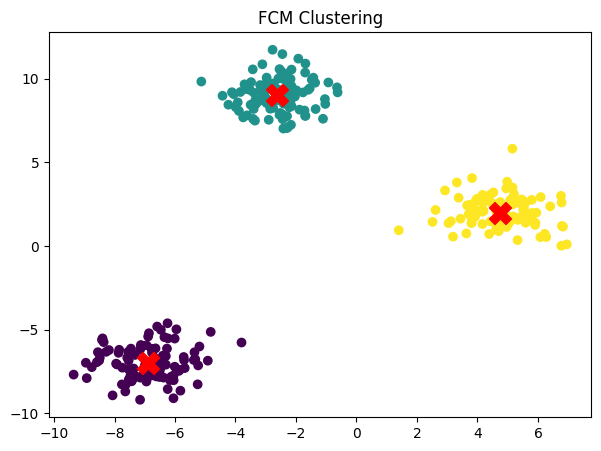

Iterations: 10


In [ ]:
# Testing
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(
    n_samples=300,
    centers=3,
    random_state=42
)

centers, U, iters = fuzzy_c_means(X, c=3)

labels = np.argmax(U, axis=1)

plt.figure(figsize=(7,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')
plt.scatter(
    centers[:,0],
    centers[:,1],
    c='red',
    marker='X',
    s=250
)
plt.title("FCM Clustering")
plt.show()

print("Iterations:", iters)

Apply your `fuzzy_c_means()` implementation to a grayscale image segmentation task.

Steps:
- Load a grayscale image (e.g., from `Pillow`) and flatten it to a 1-D array.
- Apply FCM with 3 clusters.
- Assign each pixel to the cluster with highest membership and reconstruct the segmented image.
- Display the original and segmented images side-by-side.
- Report the runtime and mean squared difference between original and segmented image.

Runtime: 29.886595010757446 seconds
Iterations: 65
Mean Squared Difference (MSE): 490.7948688812658


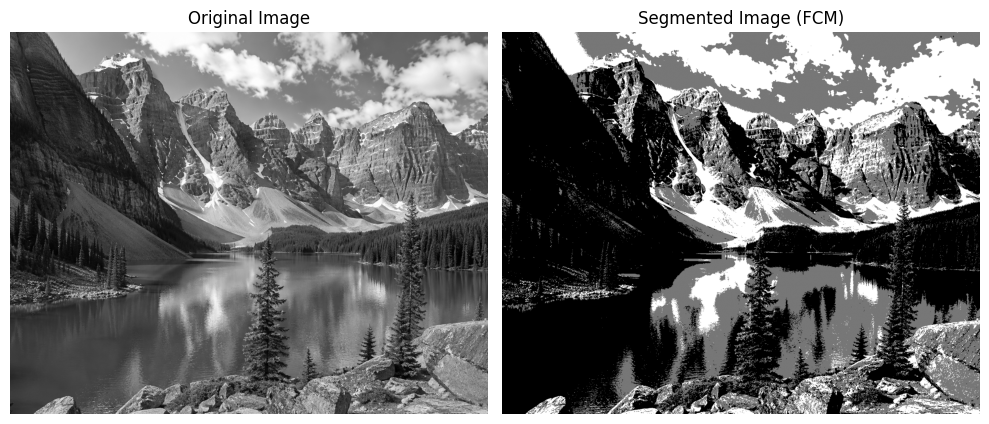

In [12]:
# Q2: Fuzzy C-Means Image Segmentation

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import time

# Load grayscale image
img = Image.open("image.png").convert("L")   # Replace with your image filename
img_arr = np.array(img)

# Flatten image pixels
pixels = img_arr.flatten().reshape(-1, 1)

# Run FCM
start = time.time()

centers, U, iterations = fuzzy_c_means(
    pixels,
    c=3,
    m=2.0
)

runtime = time.time() - start

# Assign pixels to cluster with highest membership
labels = np.argmax(U, axis=1)

# Reconstruct segmented image
segmented_pixels = centers[labels].flatten()
segmented_img = segmented_pixels.reshape(img_arr.shape)

# Compute Mean Squared Difference
mse = np.mean(
    (img_arr.astype(float) - segmented_img.astype(float))**2
)

# Report results
print("Runtime:", runtime, "seconds")
print("Iterations:", iterations)
print("Mean Squared Difference (MSE):", mse)

# Display images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_arr, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(segmented_img, cmap='gray')
plt.title("Segmented Image (FCM)")
plt.axis('off')

plt.tight_layout()
plt.show()

Investigate the effect of fuzzifier `m` on clustering.

For a fixed dataset (`make_blobs` with 3 clusters):
- Run your FCM for `m = 1.5`, `2.0`, `2.5`, `3.0`.
- For each, report:
- Final objective function value
- Number of iterations
- Plot of data colored by dominant membership
Write a short analysis: how does increasing `m` affect membership sharpness and convergence?


m = 1.5
Objective Function = 565.9734
Iterations = 8


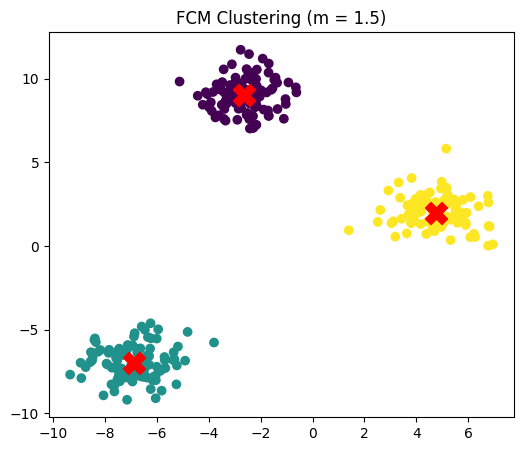


m = 2.0
Objective Function = 540.7630
Iterations = 10


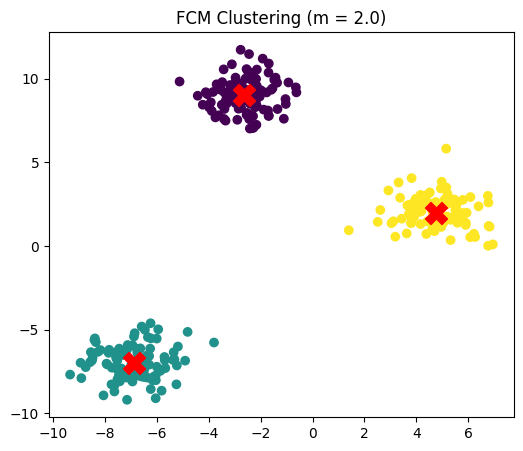


m = 2.5
Objective Function = 461.7992
Iterations = 12


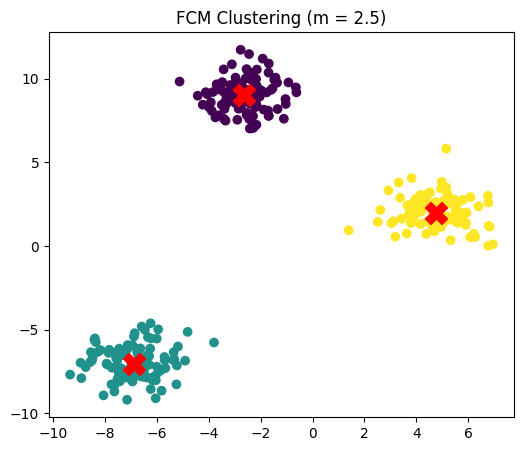


m = 3.0
Objective Function = 353.6156
Iterations = 14


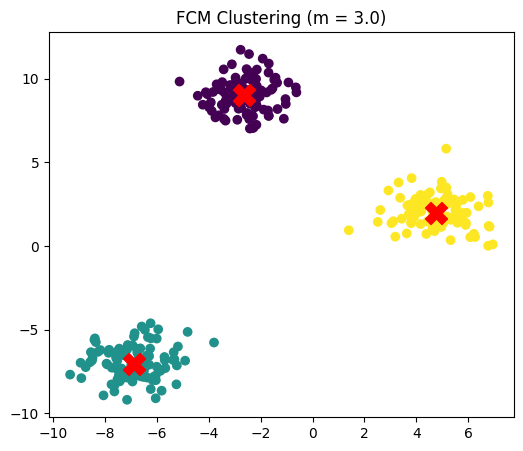

In [15]:
# Q3: Effect of Fuzzifier m on FCM

from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

# Dataset
X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

# Objective Function
def objective_function(X, centers, U, m):
    J = 0
    for j in range(len(centers)):
        dist_sq = np.linalg.norm(X - centers[j], axis=1)**2
        J += np.sum((U[:, j]**m) * dist_sq)
    return J

m_values = [1.5, 2.0, 2.5, 3.0]

for m in m_values:

    centers, U, iterations = fuzzy_c_means(
        X,
        c=3,
        m=m
    )

    J = objective_function(
        X,
        centers,
        U,
        m
    )

    labels = np.argmax(U, axis=1)

    print(f"\nm = {m}")
    print(f"Objective Function = {J:.4f}")
    print(f"Iterations = {iterations}")

    plt.figure(figsize=(6,5))
    plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')
    plt.scatter(
        centers[:,0],
        centers[:,1],
        marker='X',
        s=250,
        c='red'
    )
    plt.title(f"FCM Clustering (m = {m})")
    plt.show()

**Short Analysis**

As the fuzzifier m increases, memberships become softer and points share membership among multiple clusters. Lower m values produce crisper clustering. Higher m values generally require more iterations to converge because membership updates become smoother. Cluster boundaries become less distinct as m increases.

Use Partition Coefficient (PC) and Partition Entropy (PE) as validity indices.

Implement:
- `partition_coefficient(U)` = \( \frac{1}{N} \sum_{i=1}^N \sum_{j=1}^c u_{ij}^2 \)
- `partition_entropy(U)` = \( -\frac{1}{N} \sum_{i=1}^N \sum_{j=1}^c u_{ij} \log u_{ij} \)

For `k = 2 … 6`, run FCM on the Iris dataset (`load_iris()`) and plot PC and PE vs. `k` on a single plot (one curve increasing, one decreasing).
Select and report the best `k` based on both indices.

In [16]:
def partition_coefficient(U):
    N = U.shape[0]
    return np.sum(U**2)/N

def partition_entropy(U):
    N = U.shape[0]
    return -np.sum(
        U*np.log(U+1e-10)
    )/N

In [17]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data

In [18]:
pc_vals = []
pe_vals = []

k_values = range(2,7)

for k in k_values:

    _,U,_ = fuzzy_c_means(
        X,
        c=k
    )

    pc_vals.append(
        partition_coefficient(U)
    )

    pe_vals.append(
        partition_entropy(U)
    )

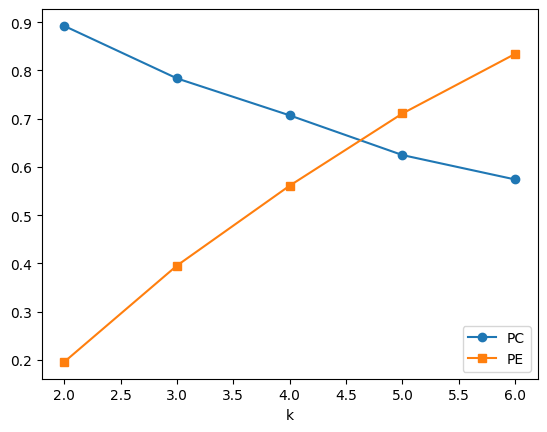

In [19]:
plt.plot(
    k_values,
    pc_vals,
    marker='o',
    label='PC'
)

plt.plot(
    k_values,
    pe_vals,
    marker='s',
    label='PE'
)

plt.legend()
plt.xlabel("k")
plt.show()

In [20]:
best_pc = k_values[np.argmax(pc_vals)]
best_pe = k_values[np.argmin(pe_vals)]

print("Best k from PC:", best_pc)
print("Best k from PE:", best_pe)

Best k from PC: 2
Best k from PE: 2


Perform document clustering with FCM using TF-IDF vectors.

Steps:
- Load up to 3,000 documents from `sklearn.datasets.fetch_20newsgroups` (select “rec.autos”, “sci.space”, “talk.politics.misc”).
- Compute TF-IDF vectors (`TfidfVectorizer`) and apply dimensionality reduction (`TruncatedSVD`, 50 components).
- Run FCM with `c = 3`.
- Assign cluster labels by highest membership and compare against true categories using Adjusted Rand Index (ARI).
- Report ARI and display a bar chart of average membership per cluster.

In [21]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import adjusted_rand_score

In [23]:
cats = [
    "rec.autos",
    "sci.space",
    "talk.politics.misc"
]

data = fetch_20newsgroups(
    categories=cats,
    remove=('headers','footers','quotes')
)

docs = data.data[:3000]
true_labels = data.target[:3000]

In [24]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X = tfidf.fit_transform(docs)

In [25]:
svd = TruncatedSVD(
    n_components=50,
    random_state=42
)

X_reduced = svd.fit_transform(X)

In [26]:
centers,U,_ = fuzzy_c_means(
    X_reduced,
    c=3
)

pred_labels = np.argmax(
    U,
    axis=1
)

In [27]:
ari = adjusted_rand_score(
    true_labels,
    pred_labels
)

print("ARI:", ari)

ARI: 0.0030739704115532594


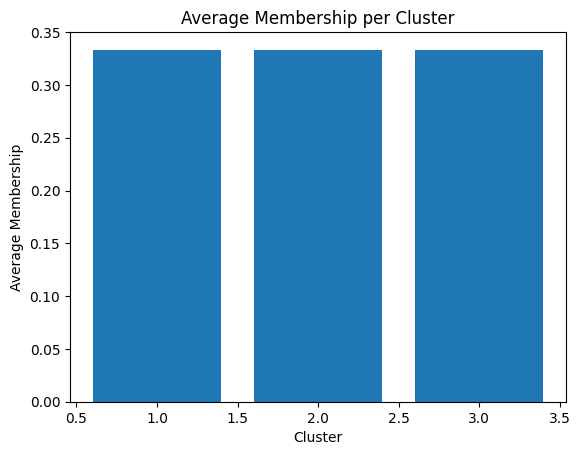

In [28]:
avg_membership = np.mean(
    U,
    axis=0
)

plt.bar(
    range(1,4),
    avg_membership
)

plt.xlabel("Cluster")
plt.ylabel("Average Membership")
plt.title("Average Membership per Cluster")
plt.show()